Total samples: 328
Number of intents: 11


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/1000
Time required: 1.44 seconds
Train Loss: 2.4007 | Train Acc: 0.1756
Val Loss: 2.3848 | Val Acc: 0.1667
Train Precision: 0.0309 | Train Recall: 0.0799
Train Macro F1: 0.0337 | Train Micro F1: 0.1756
Val Precision: 0.0152 | Val Recall: 0.0909
Val Macro F1: 0.0260 | Val Micro F1: 0.1667

Epoch 2/1000
Time required: 0.64 seconds
Train Loss: 2.3530 | Train Acc: 0.1832
Val Loss: 2.3600 | Val Acc: 0.1667
Train Precision: 0.1212 | Train Recall: 0.0853
Train Macro F1: 0.0399 | Train Micro F1: 0.1832
Val Precision: 0.0152 | Val Recall: 0.0909
Val Macro F1: 0.0260 | Val Micro F1: 0.1667

Epoch 3/1000
Time required: 0.64 seconds
Train Loss: 2.3363 | Train Acc: 0.2137
Val Loss: 2.3359 | Val Acc: 0.1667
Train Precision: 0.1405 | Train Recall: 0.1007
Train Macro F1: 0.0499 | Train Micro F1: 0.2137
Val Precision: 0.0152 | Val Recall: 0.0909
Val Macro F1: 0.0260 | Val Micro F1: 0.1667

Epoch 4/1000
Time required: 0.65 seconds
Train Loss: 2.2969 | Train Acc: 0.2176
Val Loss: 2.3119 | Val Acc

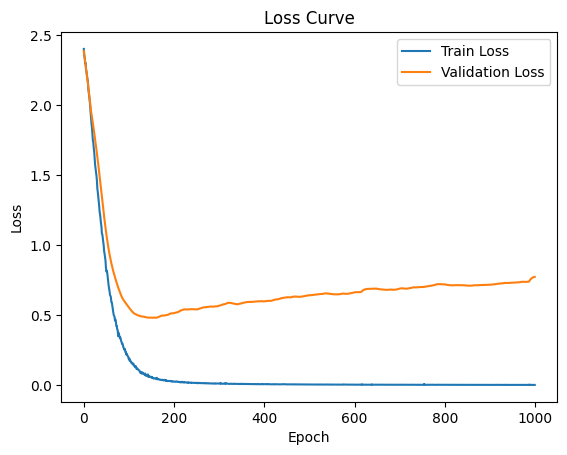

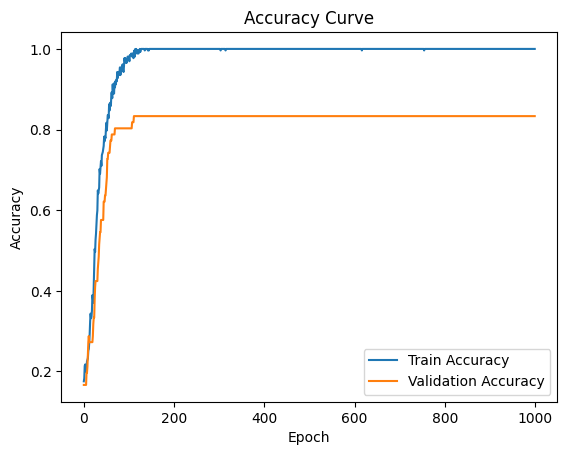

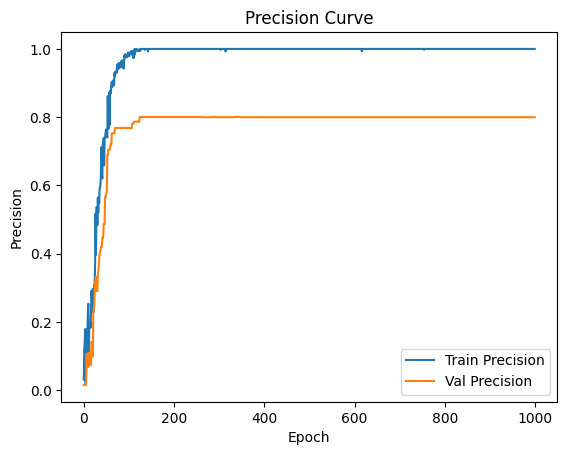

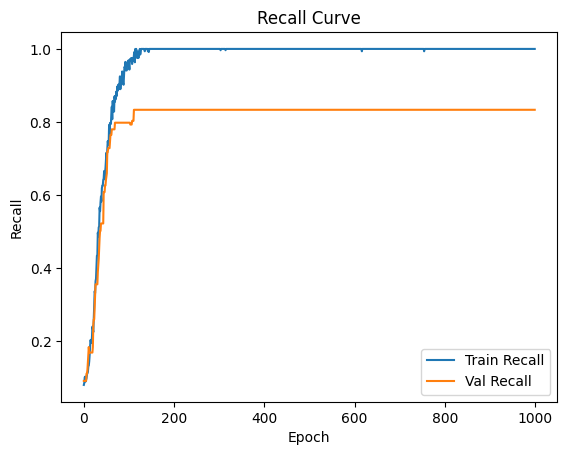

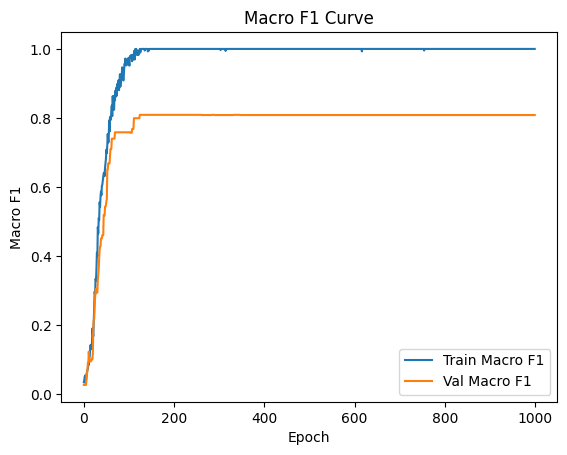

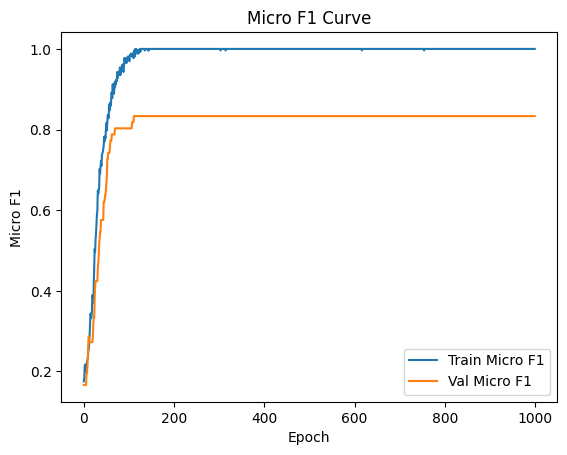

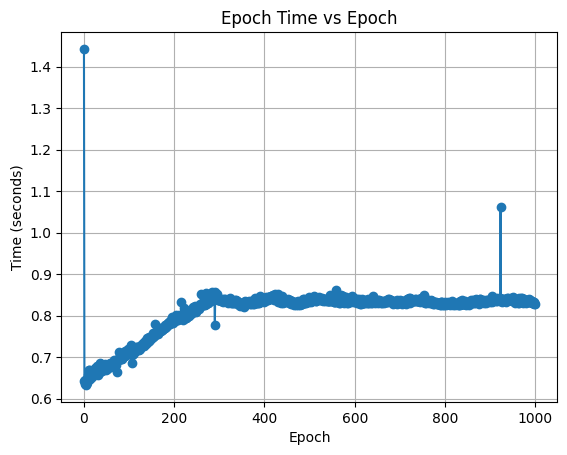

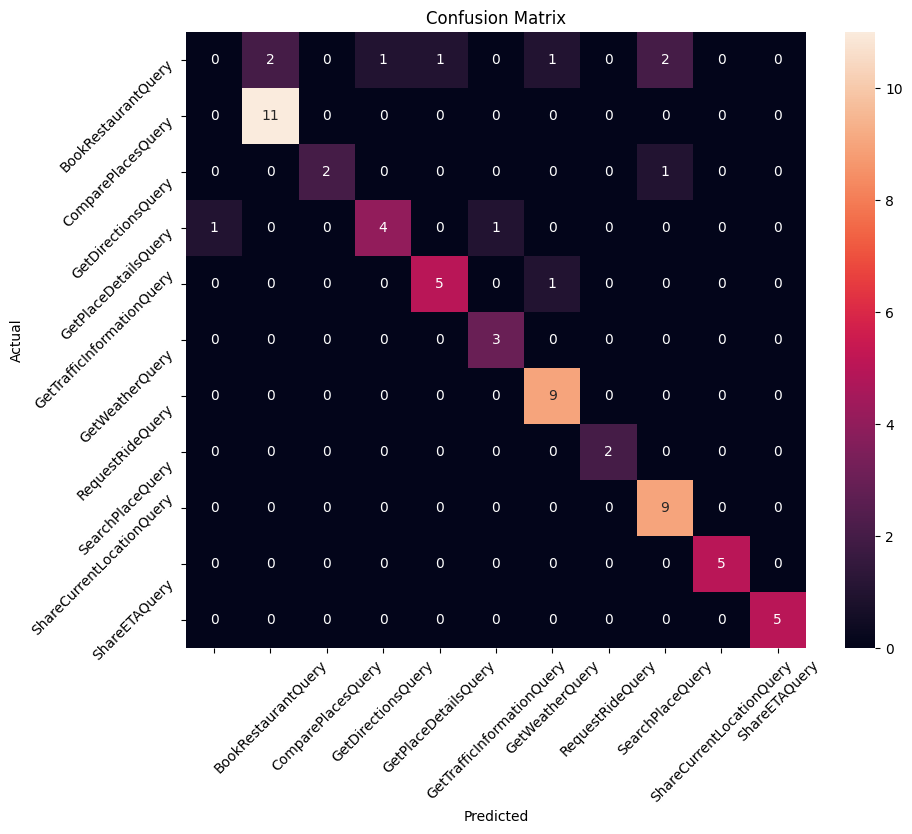


Final Classification Report:
                            precision    recall  f1-score   support

                                 0.00      0.00      0.00         7
       BookRestaurantQuery       0.85      1.00      0.92        11
        ComparePlacesQuery       1.00      0.67      0.80         3
        GetDirectionsQuery       0.80      0.67      0.73         6
      GetPlaceDetailsQuery       0.83      0.83      0.83         6
GetTrafficInformationQuery       0.75      1.00      0.86         3
           GetWeatherQuery       0.82      1.00      0.90         9
          RequestRideQuery       1.00      1.00      1.00         2
          SearchPlaceQuery       0.75      1.00      0.86         9
 ShareCurrentLocationQuery       1.00      1.00      1.00         5
             ShareETAQuery       1.00      1.00      1.00         5

                  accuracy                           0.83        66
                 macro avg       0.80      0.83      0.81        66
              we

In [1]:
import json
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import BertTokenizer, BertModel
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import warnings
from sklearn.metrics import classification_report, f1_score
import time
warnings.filterwarnings("ignore")

# 1. LOAD DATASET
with open("/kaggle/input/datasets/blank1508/snips-nlu/benchmark_data (1).json") as f:
    data = json.load(f)
texts = []
labels = []
for domain in data["domains"]:
    for intent in domain["intents"]:
        for query in intent["queries"]:
            try:
                text = query["text"]
                label = query["results_per_service"]["Snips"]["classified_intent"]
                texts.append(text)
                labels.append(label)
            except:
                continue

# Encode labels
unique_labels = sorted(list(set(labels)))
np.save("unique_labels.npy", np.array(unique_labels))
label2id = {l: i for i, l in enumerate(unique_labels)}
id2label = {i: l for l, i in label2id.items()}
labels = [label2id[l] for l in labels]
print(f"Total samples: {len(texts)}")
print(f"Number of intents: {len(unique_labels)}")

# 2. DATASET CLASS
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
class SnipsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=32,
            return_tensors="pt" )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx]) }
dataset = SnipsDataset(texts, labels)

# Train-test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# 3. MODEL (FREEZE BERT)
class BERTIntentClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        # # Freeze encoder
        # for param in self.bert.parameters():
        #     param.requires_grad = False
        for name, param in self.bert.named_parameters():
          if "encoder.layer.10" in name or "encoder.layer.11" in name:
              param.requires_grad = True
          else:
              param.requires_grad = False
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(cls_output)
        return self.classifier(x)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BERTIntentClassifier(len(unique_labels)).to(device)

# 4. TRAINING SETUP
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5)

# 5. TRAIN FUNCTION
from sklearn.metrics import precision_score, recall_score, f1_score

def train_epoch():
    model.train()
    total_loss = 0
    preds_all = []
    labels_all = []

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)

    precision = precision_score(labels_all, preds_all, average='macro', zero_division=0)
    recall = recall_score(labels_all, preds_all, average='macro', zero_division=0)
    macro_f1 = f1_score(labels_all, preds_all, average='macro', zero_division=0)
    micro_f1 = f1_score(labels_all, preds_all, average='micro', zero_division=0)

    return total_loss / len(train_loader), acc, precision, recall, macro_f1, micro_f1

# 6. EVALUATION FUNCTION
def evaluate():
    model.eval()
    preds_all = []
    labels_all = []
    total_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)
            total_loss += loss.item()
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    acc = accuracy_score(labels_all, preds_all)
    precision = precision_score(labels_all, preds_all, average='macro', zero_division=0)
    recall = recall_score(labels_all, preds_all, average='macro', zero_division=0)
    macro_f1 = f1_score(labels_all, preds_all, average='macro', zero_division=0)
    micro_f1 = f1_score(labels_all, preds_all, average='micro', zero_division=0)
    return acc, total_loss / len(test_loader), preds_all, labels_all, precision, recall, macro_f1, micro_f1

# 7. TRAIN LOOP + CHECKPOINTING
best_acc = 0
num_epochs = 1000
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_precisions = []
train_recalls = []
train_macro_f1s = []
train_micro_f1s = []
val_precisions = []
val_recalls = []
val_macro_f1s = []
val_micro_f1s = []
epoch_times = []
for epoch in range(num_epochs):
    start_time = time.time()   
    train_loss, train_acc, tr_prec, tr_rec, tr_macro_f1, tr_micro_f1 = train_epoch()
    val_acc, val_loss, preds, labels_true, val_prec, val_rec, val_macro_f1, val_micro_f1 = evaluate()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_precisions.append(tr_prec)
    train_recalls.append(tr_rec)
    train_macro_f1s.append(tr_macro_f1)
    train_micro_f1s.append(tr_micro_f1)
    val_precisions.append(val_prec)
    val_recalls.append(val_rec)
    val_macro_f1s.append(val_macro_f1)
    val_micro_f1s.append(val_micro_f1)
    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Time required: {epoch_time:.2f} seconds")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Train Precision: {tr_prec:.4f} | Train Recall: {tr_rec:.4f}")
    print(f"Train Macro F1: {tr_macro_f1:.4f} | Train Micro F1: {tr_micro_f1:.4f}")
    print(f"Val Precision: {val_prec:.4f} | Val Recall: {val_rec:.4f}")
    print(f"Val Macro F1: {val_macro_f1:.4f} | Val Micro F1: {val_micro_f1:.4f}\n")
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "val_loss": val_loss,
                    "val_acc": val_acc,
                
                    "val_precision": val_prec,
                    "val_recall": val_rec,
                    "val_macro_f1": val_macro_f1,
                    "val_micro_f1": val_micro_f1,
                
                    "label2id": label2id,
                    "id2label": id2label
                }, "best_model.pt")
torch.save({
    "epoch": num_epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    "train_loss": train_losses[-1],
    "train_acc": train_accuracies[-1],
    "val_loss": val_losses[-1],
    "val_acc": val_accuracies[-1],

    "val_precision": val_precisions[-1],
    "val_recall": val_recalls[-1],
    "val_macro_f1": val_macro_f1s[-1],
    "val_micro_f1": val_micro_f1s[-1],

    "label2id": label2id,
    "id2label": id2label
}, "last_model.pt")

# Loss Curve
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

# Accuracy Curve
plt.figure()
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_precisions, label="Train Precision")
plt.plot(val_precisions, label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Precision Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_recalls, label="Train Recall")
plt.plot(val_recalls, label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Recall Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_macro_f1s, label="Train Macro F1")
plt.plot(val_macro_f1s, label="Val Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1 Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_micro_f1s, label="Train Micro F1")
plt.plot(val_micro_f1s, label="Val Micro F1")
plt.xlabel("Epoch")
plt.ylabel("Micro F1")
plt.title("Micro F1 Curve")
plt.legend()
plt.show()

# Epoch Time Curve
plt.figure()
plt.plot(epoch_times, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.title("Epoch Time vs Epoch")
plt.grid()
plt.show()

# Confusion matric
cm = confusion_matrix(labels_true, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

# Classification Report
print("\nFinal Classification Report:")
print(classification_report(labels_true, preds, target_names=unique_labels, zero_division=0))

# Save curves, predicted and actual plots
np.save("train_losses.npy", np.array(train_losses))
np.save("val_losses.npy", np.array(val_losses))
np.save("train_accuracies.npy", np.array(train_accuracies))
np.save("val_accuracies.npy", np.array(val_accuracies))
np.save("train_precisions.npy", np.array(train_precisions))
np.save("val_precisions.npy", np.array(val_precisions))
np.save("train_recalls.npy", np.array(train_recalls))
np.save("val_recalls.npy", np.array(val_recalls))
np.save("train_macro_f1s.npy", np.array(train_macro_f1s))
np.save("val_macro_f1s.npy", np.array(val_macro_f1s))
np.save("train_micro_f1s.npy", np.array(train_micro_f1s))
np.save("val_micro_f1s.npy", np.array(val_micro_f1s))
np.save("val_confusion_matrix.npy", cm)
np.save("val_predictions.npy", np.array(preds))
np.save("val_true_labels.npy", np.array(labels_true))

# After training

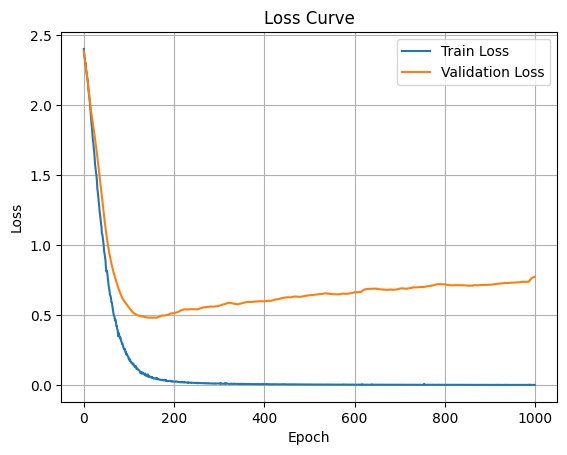

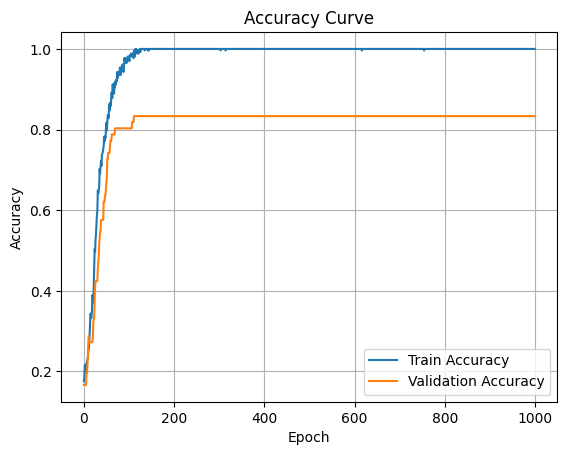

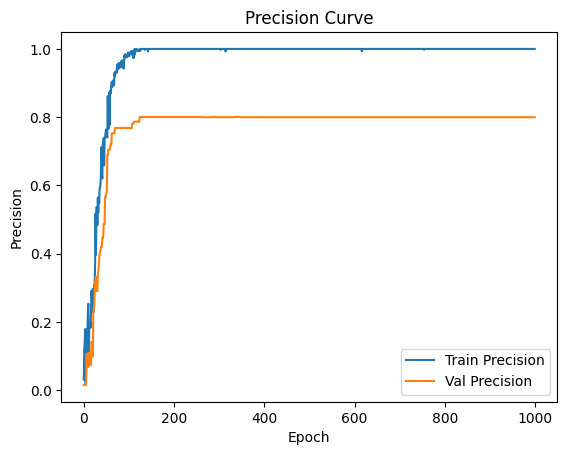

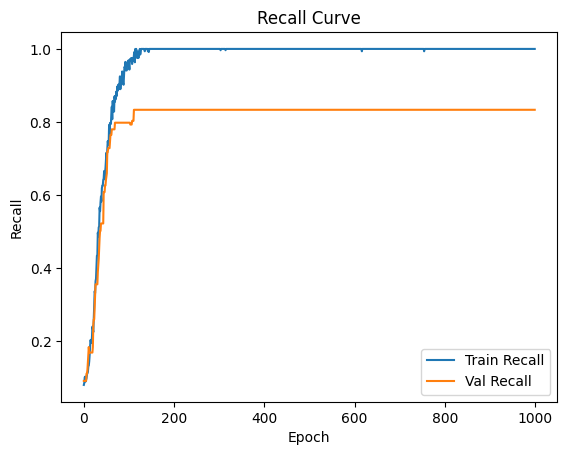

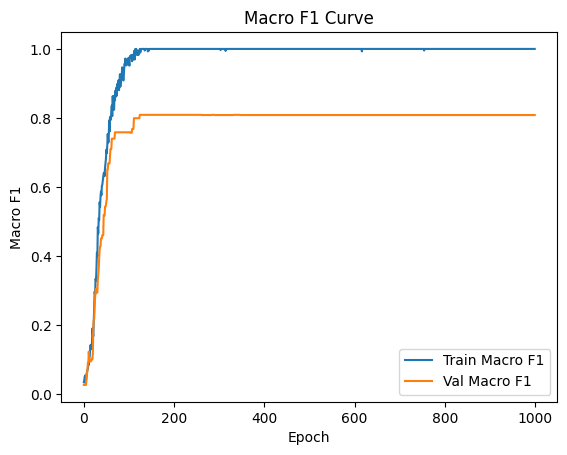

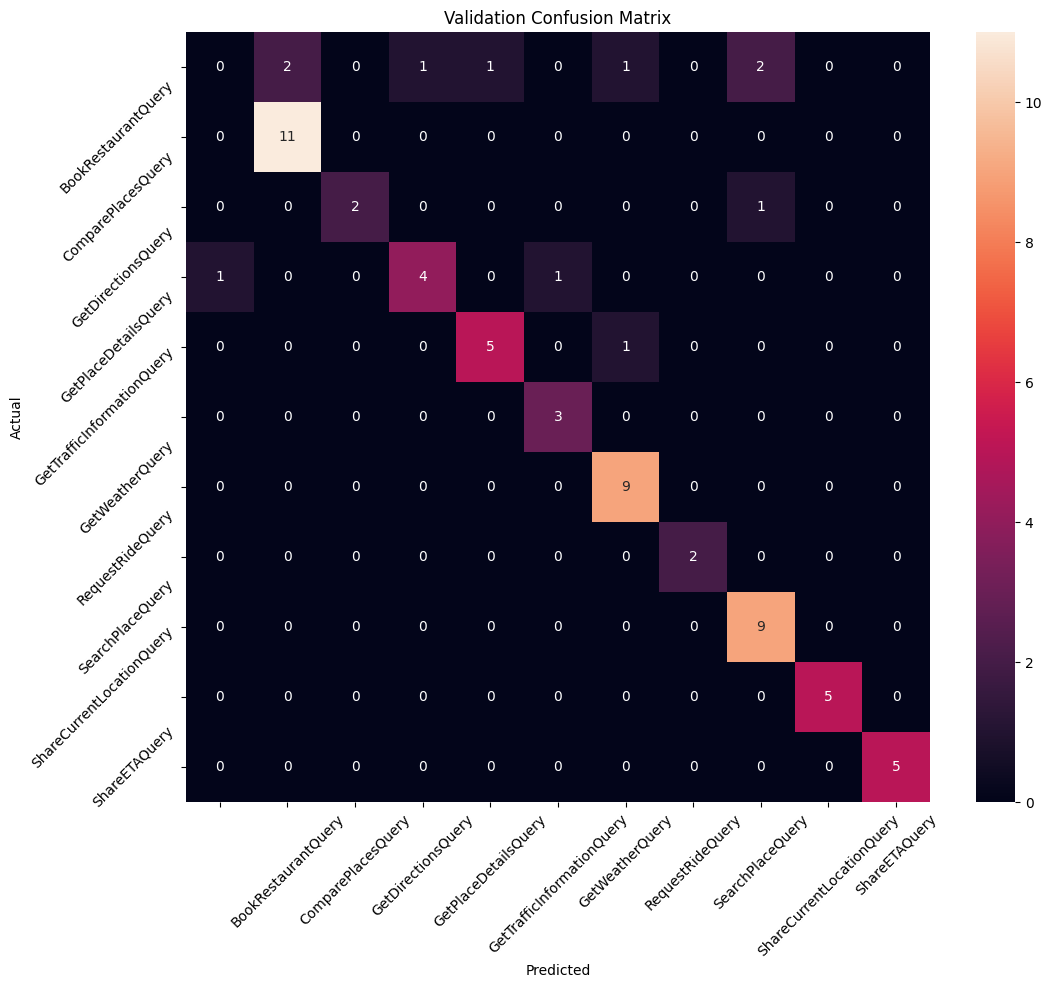

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.85      1.00      0.92        11
           2       1.00      0.67      0.80         3
           3       0.80      0.67      0.73         6
           4       0.83      0.83      0.83         6
           5       0.75      1.00      0.86         3
           6       0.82      1.00      0.90         9
           7       1.00      1.00      1.00         2
           8       0.75      1.00      0.86         9
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         5

    accuracy                           0.83        66
   macro avg       0.80      0.83      0.81        66
weighted avg       0.76      0.83      0.79        66


📦 Loaded Best Model from epoch: 112

📊 Stored Metrics:
epoch: 112
train_loss: 0.1419985294342041
train_acc: 0.9923664122137404
val_loss: 0.5133383870124817
val_acc: 0.8333333333333334
va

In [2]:
# Load arrays
train_losses = np.load("/kaggle/working/train_losses.npy")
val_losses = np.load("/kaggle/working/val_losses.npy")
train_accuracies = np.load("/kaggle/working/train_accuracies.npy")
val_accuracies = np.load("/kaggle/working/val_accuracies.npy")
train_precisions = np.load("/kaggle/working/train_precisions.npy")
val_precisions = np.load("/kaggle/working/val_precisions.npy")
train_recalls = np.load("/kaggle/working/train_recalls.npy")
val_recalls = np.load("/kaggle/working/val_recalls.npy")
train_macro_f1s = np.load("/kaggle/working/train_macro_f1s.npy")
val_macro_f1s = np.load("/kaggle/working/val_macro_f1s.npy")
train_micro_f1s = np.load("/kaggle/working/train_micro_f1s.npy")
val_micro_f1s = np.load("/kaggle/working/val_micro_f1s.npy")
cm = np.load("/kaggle/working/val_confusion_matrix.npy")
preds = np.load("/kaggle/working/val_predictions.npy")
labels_true = np.load("/kaggle/working/val_true_labels.npy")
unique_labels = np.load("/kaggle/working/unique_labels.npy")

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(train_precisions, label="Train Precision")
plt.plot(val_precisions, label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Precision Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_recalls, label="Train Recall")
plt.plot(val_recalls, label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Recall Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_macro_f1s, label="Train Macro F1")
plt.plot(val_macro_f1s, label="Val Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1 Curve")
plt.legend()
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=unique_labels,
            yticklabels=unique_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

print(classification_report(labels_true, preds))

def load_and_print_checkpoint(path, model, optimizer, device, name="Model"):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    print(f"\n📦 Loaded {name} from epoch: {checkpoint.get('epoch', 'N/A')}")
    # Print all stored metrics dynamically
    print("\n📊 Stored Metrics:")
    for key, value in checkpoint.items():
        if key in ["model_state_dict", "optimizer_state_dict"]:
            continue  # skip large tensors
        # Pretty print lists (like history)
        if isinstance(value, list):
            print(f"{key}: [length = {len(value)}]")
        else:
            print(f"{key}: {value}")
    print("-" * 50)
    return checkpoint

best_ckpt = load_and_print_checkpoint(
    "/kaggle/working/best_model.pt",
    model,
    optimizer,
    device,
    name="Best Model")
last_ckpt = load_and_print_checkpoint(
    "/kaggle/working/last_model.pt",
    model,
    optimizer,
    device,
    name="Last Model")